**Telecom Customer Churn Analysis Using Exploratory Data Analysis (EDA)**


**Business Problem Statement**

Customer churn is a major challenge in the telecommunications industry, as losing customers directly impacts revenue, profitability, and business growth. Understanding the factors that influence customer churn is essential for developing effective customer retention strategies.

This project aims to analyze customer demographics, service subscriptions, billing information, and contract details to identify the key factors associated with customer churn and provide actionable insights to improve customer retention.

**Objectives**

  -Perform data cleaning and preprocessing.

  -Analyze customer demographics, services, and billing patterns.

  -Identify key factors affecting customer churn.

  -Generate insights and recommendations to improve customer retention.

**Key Business Questions**

1. Which customer segments are most likely to churn?
2. Does customer tenure influence churn behavior?
3. How do monthly charges affect customer churn?
4. Which telecom services are associated with higher or lower churn rates?
5. How does contract type impact customer retention?
6. What are the key factors driving customer churn, and how can the company reduce it?
?


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn (2).csv')

In [4]:

df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**DESCRIBING THE DATA:**

-It has **7043 CUSTOMER RECORDS** and **21 FEATURES**
-

**DESCRIBING THE DATA COLUMNS:**

-**real numerical columns**-MonthlyCharges,TotalCharges

-**discrete numerical columns**-tenure,SeniorCitizen

-**categorical columns**-gender,partner,dependents,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,churn

-**identifier columns**-customerId

**-->HERE IDENTIFIER COLUMNS SHOULD BE DROPPED**

In [7]:
df=df.drop(columns=['customerID'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


-HERE IDENTIFIER COLUMN-**customerID** IS DROPPED


**DATA CLEANING**

In [9]:
df['TotalCharges'].dtype

dtype('O')

**Here,it shows that totalcharges as object data type.so, we have to convert this to numerical column**

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


-Here,we have changed the total charges column to numeric data type

**-->checking missing values**

In [12]:
df.isnull().any()

,0
gender,False
SeniorCitizen,False
Partner,False
Dependents,False
tenure,False
PhoneService,False
MultipleLines,False
InternetService,False
OnlineSecurity,False
OnlineBackup,False


In [13]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


*THERE ARE NO MISSING VALUES IN THE ABOVE DATASET

**-->CHECKING DUPLICATES**

In [14]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
7038,False
7039,False
7040,False
7041,False


In [15]:
df.duplicated().sum()

np.int64(22)

*THERE ARE NO DUPLICATES IN THE DATA

**-->CHECKING OUTLIERS**

In [16]:
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['MonthlyCharges'] < lower) | (df['MonthlyCharges'] > upper)]
print(len(outliers))

0


Text(0.5, 1.0, 'MONTHLY CHARGES')

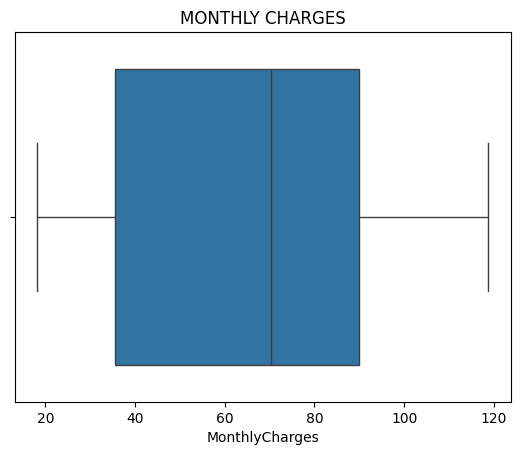

In [17]:
sns.boxplot(df,x='MonthlyCharges')
plt.title('MONTHLY CHARGES')

In [18]:
Q1 = df['TotalCharges'].quantile(0.25)
Q3 = df['TotalCharges'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['TotalCharges'] < lower) | (df['TotalCharges'] > upper)]
print(len(outliers))

0


Text(0.5, 1.0, 'TOTAL CHARGES')

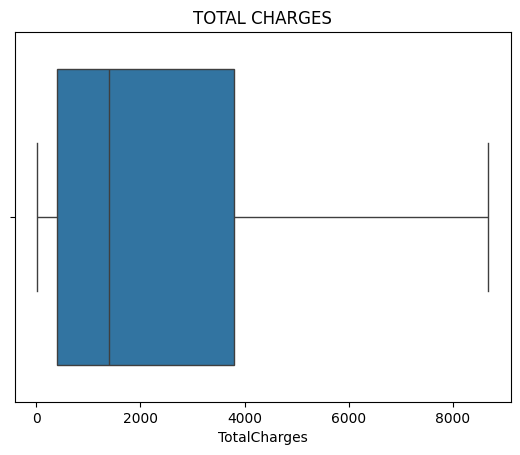

In [19]:

sns.boxplot(df,x='TotalCharges')
plt.title('TOTAL CHARGES')

In [20]:
Q1 = df['tenure'].quantile(0.25)
Q3 = df['tenure'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['tenure'] < lower) | (df['tenure'] > upper)]
print(len(outliers))

0


Text(0.5, 1.0, 'TENURE')

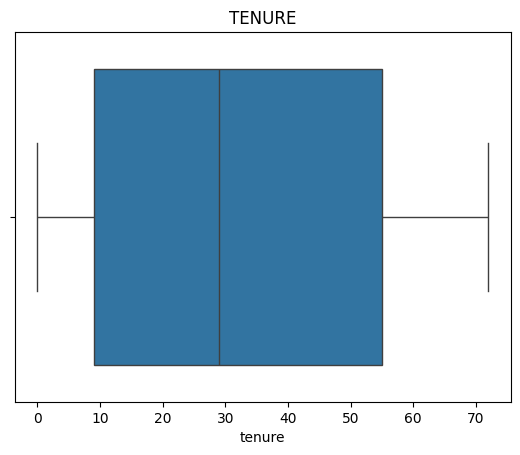

In [21]:
sns.boxplot(df,x='tenure')
plt.title('TENURE')

**-Therefore in the above data there are no outliers present**

**WE HAVE CLEANED OUR DATA BY CHECKING MISSING VALUES,DUPLICATES,OUTLIERS AND ALSO WE HAVE REMOVED UNNECESSARY COLUMNS AND ALSO WE HAVE CONVERTED THE DATA TYPES OF THE COLUMNS WHICHEVER NEEDED**

**EXPLORATARY DATA ANALYSIS**

In [22]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**TENURE DISTRIBUTION**

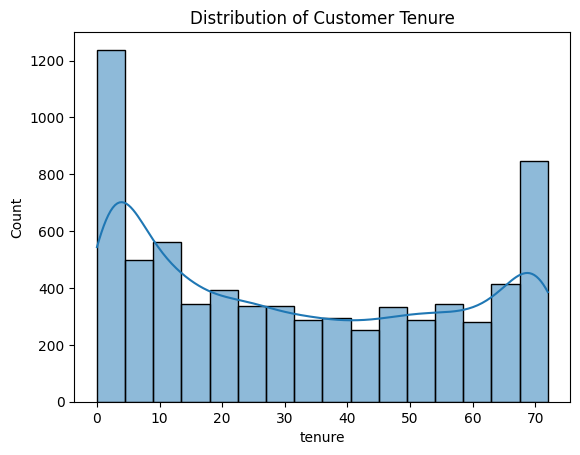

In [23]:
sns.histplot(df['tenure'], kde=True)
plt.title('Distribution of Customer Tenure')
plt.show()

**Observation:**

-Most customers have lower tenure

-The number of customers decreases as tenure increases

**MONTHLYCHARGES DISTRIBUTION**

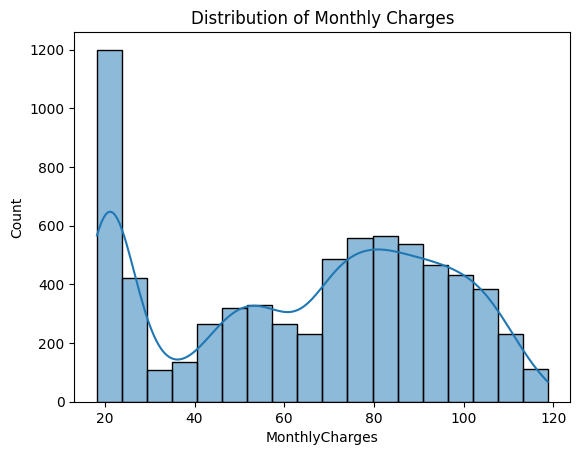

In [24]:
sns.histplot(df['MonthlyCharges'], kde=True)
plt.title('Distribution of Monthly Charges')
plt.show()

**Observation:**

-Monthly charges are spread across different price ranges

-Customers are distributed across low, medium, and high charge categories

**TOTALCHARGES DISTRIBUTION**

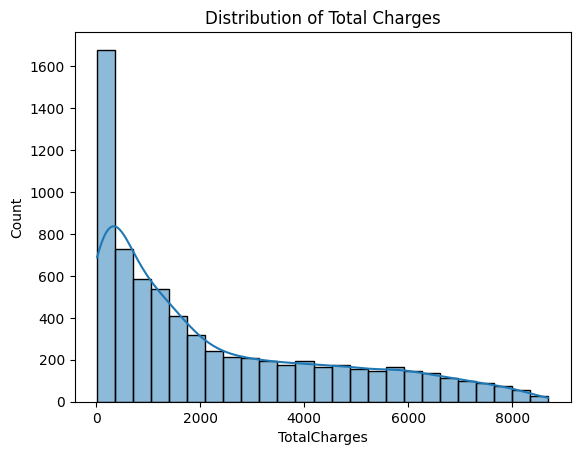

In [25]:
sns.histplot(df['TotalCharges'], kde=True)
plt.title('Distribution of Total Charges')
plt.show()

**Observation:**

-The distribution is positively skewed

-Most customers have lower total charges, while a few customers have very high total charges

**what percentage of customers churned ?**

In [26]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


-HERE,THE RETAINED CUSTOMERS ARE ABOVE 5000

-AND CHURNED CUSTOMERS ARE AROUND 1800


In [27]:
(df['Churn'].value_counts()/len(df))*100

,count
Churn,
No,73.463013
Yes,26.536987


-THE CHURNED PERCENTAGE IS 26.5%

-THEREFORE 26.5% CUSTOMERS ARE CHURNED FROM THE TELECOM COMPANIES

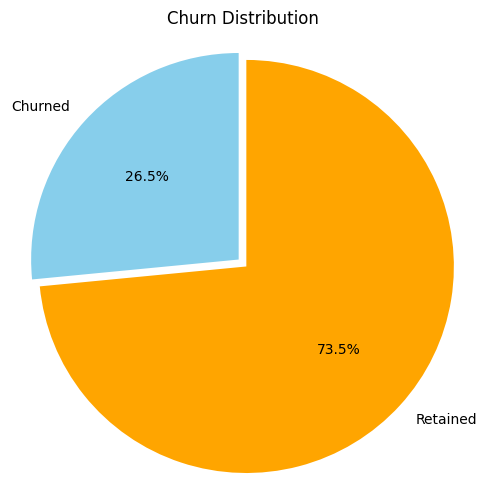

In [62]:
labels = ["Churned", "Retained"]
sizes = [1869, 5174]
colors = [ "skyblue","orange"]
plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    explode=(0.05, 0)  # highlights churned slice
)

plt.title("Churn Distribution")
plt.axis("equal")  # ensures circle shape

plt.show()

-IT SHOWS THE VISUAL REPRESENTATION OF CUSTMER CHURN DATA

**TENURE VS CHURN**

In [29]:
df['Tenure_Group'] = pd.cut(df['tenure'],bins=[0, 12, 24, 48, 72],labels=['0-12 Months', '13-24 Months', '25-48 Months', '49-72 Months'])

In [30]:
pd.crosstab(df['Tenure_Group'],df['Churn'],normalize='index')*100

Churn,No,Yes
Tenure_Group,,
0-12 Months,52.321839,47.678161
13-24 Months,71.289062,28.710938
25-48 Months,79.611041,20.388959
49-72 Months,90.486824,9.513176


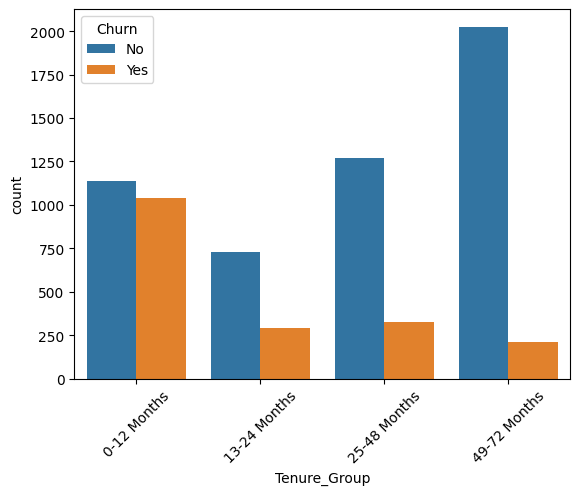

In [31]:
sns.countplot(x='Tenure_Group',hue='Churn',data=df)
plt.xticks(rotation=45)
plt.show()

**OBSERVATIONS**

-HERE,0-12 MONTHS HAS THE HIGHEST CHURN

-AND THE CUSTOMERS WITH TENURE 49-72 MONTHS ARE HAVING LOW CHURN

**INSIGHTS**

-CUSTOMERS IN **0-12** MONTHS HAVE THE HIGHEST CHURN

-CHURN DECREASES AS TENURE INCREASES

-LONGTERM CUSTOMERS ARE MORE LOYAL

**MONTHLYCHARGES VS CHURN**

In [32]:
df.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


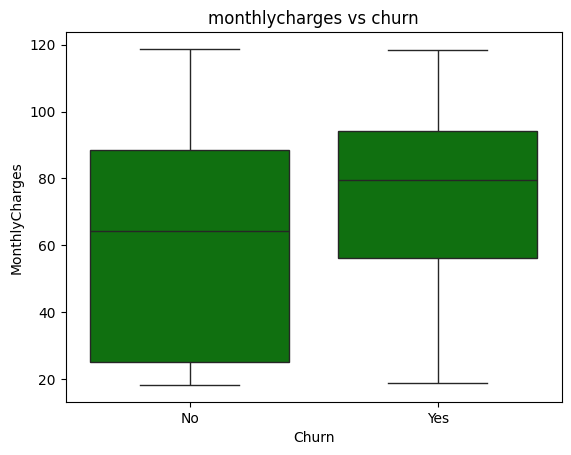

In [33]:
sns.boxplot(df,x='Churn',y='MonthlyCharges',color='green')
plt.title('monthlycharges vs churn')
plt.show()

-HERE,WE CAN OBSERVE THAT THE AVERAGE MONTHLY CHARGES WITH RESPECT TO CHURN

-THE AVERAGE MONTHLY CHARGES OF RETAINED CUSTOMERS IS APPROXIMATELY 61.2

-THE AVERAGE MONTHLY CHARGES OF CHURNED CUSTOMERS IS APPROXIMATELY 74.5

-BY THIS,THE CUSTOMERS WITH HIGH MONTHLY CHARGES ARE CHURNED MORE

**TOTALCHARGES VS CHURN**

In [34]:
df.groupby('Churn')['TotalCharges'].mean()

,TotalCharges
Churn,
No,2555.344141
Yes,1531.796094


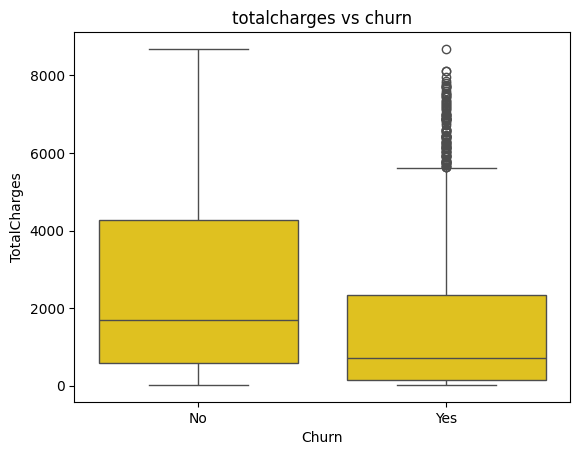

In [35]:
sns.boxplot(df,x='Churn',y='TotalCharges',color='gold')
plt.title('totalcharges vs churn')
plt.show()

-HERE WE CAN OBSERVE THAT THE AVERAGE OF TOTAL CHARGES WITH RESPECT TO CHURN

-THE CUSTOMERS WHO ARE NOT CHURNED ARE ABLE TO PAY LARGE AMOUNT.SO,THEY WOULD PAY HIGH AMOUNT COMPARED TO CHURNED

**GENDER VS CHURN**

In [36]:
pd.crosstab(df['gender'],df['Churn'],normalize='index')*100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


-HERE,THERE IS NO DIFFERENCE WITH RESPECT TO GENDER COLUMN

-MALE AND FEMALE CUSTOMERS ARE EQUALLY RETAINED AND CHURNED

Text(0.5, 1.0, 'CHURN VS GENDER')

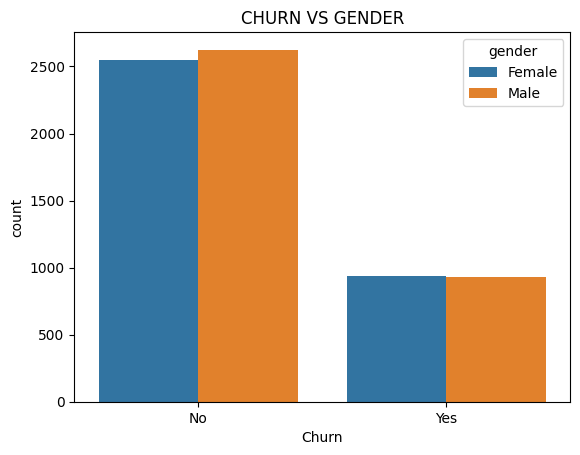

In [37]:
sns.countplot(df,x='Churn',hue='gender')
plt.title('CHURN VS GENDER')

**OBSERVATIONS:**

-HERE,THERE IS NO MUCH DIFFERENCE BETWEEN MALE AND FEMALE IN BOTH CASES(CHURNED AND RETAINED)

-BOTH FEMALE ARE CHURNED EQUALLY

-BOTH ARE VERY CLOSELY RETAINED

**INSIGHTS:**

-THE GENDER IS NOT EFFECTING IN CHURN

-MALE AND FEMALE CUSTOMERS ARE SIMILARLY REATINED AND CHURNED

**PARTNER VS CHURN**

In [38]:
pd.crosstab(df['Partner'],df['Churn'],normalize='index')*100

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


-HERE,THE CUSTOMERS WITHOUT PARTNERS ARE MORE CHURNED

-AND ALSO SLIGHTLY MORE RETAINED CUSTOMERS ARE WITH PARTNERS ONLY

Text(0.5, 1.0, 'CHURN VS PARTNER')

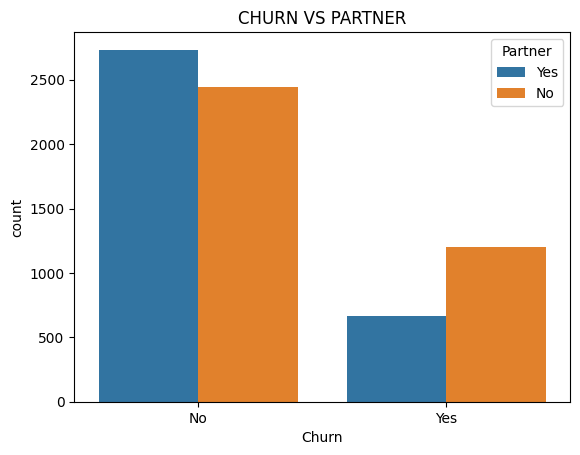

In [39]:
sns.countplot(df,x='Churn',hue='Partner')
plt.title('CHURN VS PARTNER')

**OBSERVATIONS:**

-HERE,WE CAN OBSERVE THAT THE CUSTOMERS HAVING PARTNERS ARE MORE RETAINED CUSTOMERS AND ALSO THEY ARE LESS CHURNED

-THE CUSTOMERS WITHOUT PARTNERS ARE CHURNED MORE

-THE CUSTOMERS WITHOUT PARTNERS ARE LESS RETAINED AND HIGHLY CHURNED COMPARED TO TH CUSTOMEERS WITH PARTNERS

**INSIGHTS:**

-THERE IS NOT AFFECT ON CHURN FROM THE CUSTOMERS HAVING PARTNERS

-customers without partners show a higher tendency to leave the telecom company

**DEPENDENTS VS CHURN**

In [40]:
pd.crosstab(df['Dependents'],df['Churn'],normalize='index')*100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


-HERE,THE CUSTOMERS WITHOUT DEPENDENTS ARE HEAVILY CHURNED

-AND ALSO CUSTOMERS WITH DEPENDENTS ARE VERY LESS CHURNED


Text(0.5, 1.0, 'CHURN VS DEPENDENTS')

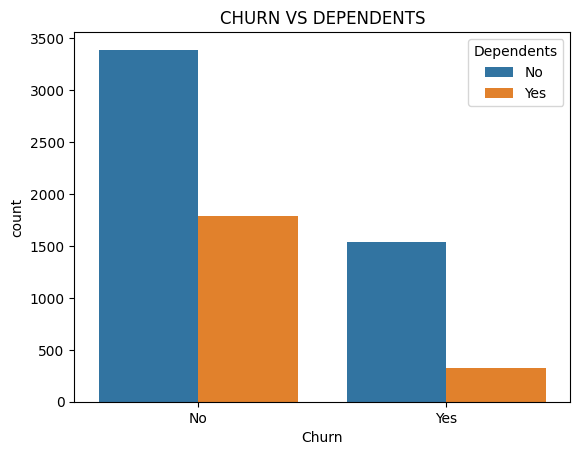

In [41]:
sns.countplot(df,x='Churn',hue='Dependents')
plt.title('CHURN VS DEPENDENTS')

**OBSERVATIONS:**

-HERE,WE CAN OBSERVE THAT THE CUSTOMERS WITH DEPENDENTS ARE MORE RETAINED ONES AND ALSO THERE IS LESS CHURN RATE

-THE CUSTOMERS WITHOUT DEPENDENTS ARE HIGHLY CHURNED

**INSIGHTS:**

-Having dependents appears to be associated with better customer retention

-Customers with dependents demonstrate more stable retention behavior and are less likely to churn

-Customers without dependents are more likely to leave the telecom company

-The higher number of retained customers without dependents is likely due to the larger size of that customer group, not necessarily because they have a better retention rate

**INTERNET SERVICE VS CHURN**

In [42]:
pd.crosstab(df['InternetService'],df['Churn'],normalize='index')*100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


-WE CAN OBSERVE THAT CUSTOMERS WITHOUT INTERNET SERVICE HAS VERY LESS CHURN AND ALSO HIGH RETENTION RATE COMPARED TO OTHER CATEGORIES

-AND DSL ALSO HAS BETTER RETENTION RATE AND LESS CHURN RATE COMPARE TO FIBER OPTIC SERVICE

-FIBER OPTIC SERVICE HAS HIGH CHURN RATE COMPARED TO OTHER CATEGORIES AND ALSO VERY LESS RETENTION RATE

Text(0.5, 1.0, 'CHURN VS INTERNETSERVICE')

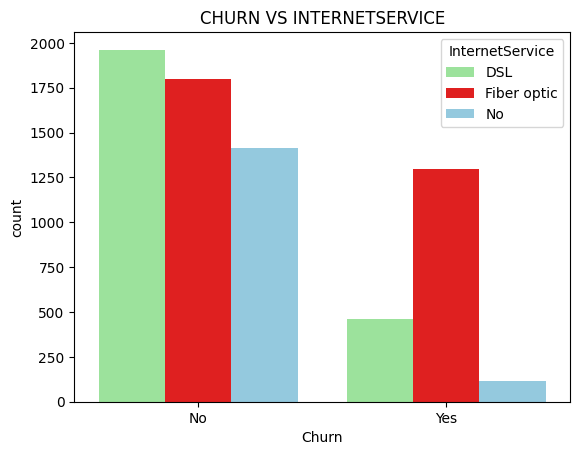

In [43]:
sns.countplot(df,x='Churn',hue='InternetService',palette=('lightgreen','red','skyblue'))
plt.title('CHURN VS INTERNETSERVICE')

**OBSERVATIONS:**

-WE CAN OBSERVE THAT CUSTOMERS WITHOUT INTERNET SERVICE HAS VERY LESS CHURN AND ALSO HIGH RETENTION RATE COMPARED TO OTHER CATEGORIES

-AND DSL ALSO HAS BETTER RETENTION RATE AND LESS CHURN RATE COMPARE TO FIBER OPTIC SERVICE

-FIBER OPTIC SERVICE HAS HIGH CHURN RATE COMPARED TO OTHER CATEGORIES AND ALSO VERY LESS RETENTION RATE

**INSIGHTS:**

-CUSTOMERS WITH FIBER OPTIC SERVICE HAS THE HIGHEST CHURN RATE COMPARED TO OTHER INETERNET SERVICE CATEGORIES

-DSL CUSTOMERS IS HAVING HIGH CHURN RATE COMPARED TO THE CUSTOMERS WITHOUT INTERNET SERVICE

-CUSTOMERS WITHOUT INTERNETSERVICE HAS LESS CHURN AND THEY ARE THE HIGHLY RETAINED CUSTOMERS

-INTERNET SERVICE HAS A SIGNIFICANT IMPACT ON THE CUSTOMER CHURN

**ONLINESECURITY VS CHURN**

In [44]:
pd.crosstab(df['OnlineSecurity'],df['Churn'],normalize='index')*100

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


-WE CAN OBSERVE THAT THE THE CUSTOMERS WITHOUT ONLINE SECURITY ARE CHURNED MORE

-ALSO WITH NOT HAVING ANY INTERNET HAS BEEN CHURNED LESS AND THEY ARE LESS

-THE CUSTOMERS WITH ONLINESECIURITY ARE CHURNED LESS AND ALSO RETENTION RATE IS HIGH.

Text(0.5, 1.0, 'CHURN VS ONLINESECURITY')

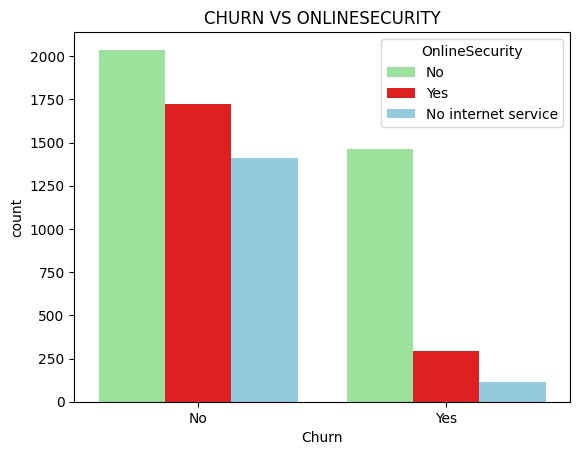

In [45]:
sns.countplot(df,x='Churn',hue='OnlineSecurity',palette=('lightgreen','red','skyblue'))
plt.title('CHURN VS ONLINESECURITY')

**OBSERVATIONS:**

-HERE,CLEARLY SHOWS THAT THE CUSTOMERS WITH ONLINE SECURITY,THE CHURN RATE IS LOW AND RETENTION RATE IS HIGH

-WHEREAS CUSTOMERS WITHOUT ONLINE SECURITY ARE HAVING HIGH CHURN RATE

-BUT IN THE CASE OF NO INTERNET CONNECTION THE CHURN RATE IS VERY LOW

**INSIGHT:**

-ONLINESECURITY IS MODERATELY AFFECTING THE CUSTOMER CHURN

-CUSTOMERS WITH ONLINE SECURITY WERE LESS CHURNED

-CUSTOMERS WITHOUT ONLINESECURITY WERE CHURNED MORE

**TECH SUPPORT VS CHURN**

In [46]:
pd.crosstab(df['TechSupport'],df['Churn'],normalize='index')*100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


=HERE,THE CUSTOMERS WITH TECH SUPPORT ARE MORE RETAINED AND LESS CHURNED COMPARED TO CUTOMERS WITHOUT TECHSUPPORT

-AND ALSO THE CUSTOMERS WITHOUT INTERNET CONNECTION ARE CHURNED LESS AND RETAINED HIGH

Text(0.5, 1.0, 'CHURN VS TECHSUPPORT')

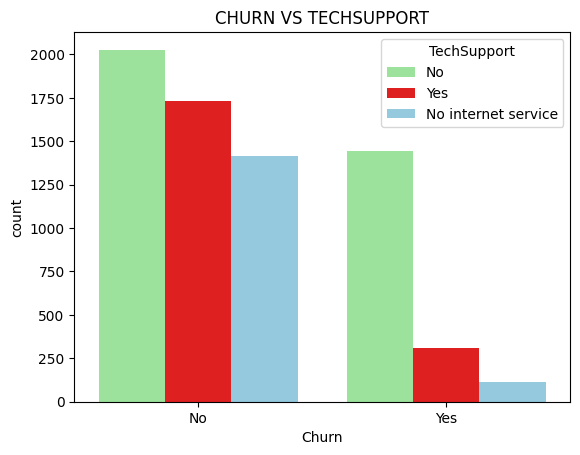

In [47]:
sns.countplot(df,x='Churn',hue='TechSupport',palette=('lightgreen','red','skyblue'))
plt.title('CHURN VS TECHSUPPORT')

-BY THIS PLOT WE CAN OBSERVE THAT,THE CUSTOMERS WITH TECH SUPPORT ARE HAVING LESS CHURN AND HIGH RETENTION RATE

-CUSTOMERS WITHOUT TECH SUPPORT ARE CHURNED MORE BY LARGELY AROUND 1500(42%)

-CUSTOMERS WITHOUT INTERNET CONNECTION ARE CHURNED LESS COMPARED TO BOTH CASES

**INSIGHT:**

-TECH SUPPORT IS STRONGLY EFFECTING THE CUSTOMER CHURN

-CUSTOMER WITH TECHNICAL SUPPORT ARE CHURNED LESS

-CUSTOMERS WITHOIUT TECHNICAL SUPPORT ARE CHURNED HIGH

**CONTRACT VS CHURN**

In [48]:
pd.crosstab(df['Contract'],df['Churn'],normalize='index')*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


-THE CUSTOMERS WITH TWO-YEAR CONTRACT ARE HAVING LESS THAN 3% CHURN RATE

-BUT WITH MONTH-TO-MONTH CONTRACT ARE HAVING VERY HIGH CHURN RATE AROUND 43%

-AND ONE YEAR CONTRACT CUSTOMERS ARE ALSO HAVING LOW CHURN RATE AROUND 11%

Text(0.5, 1.0, 'CHURN VS CONTRACT')

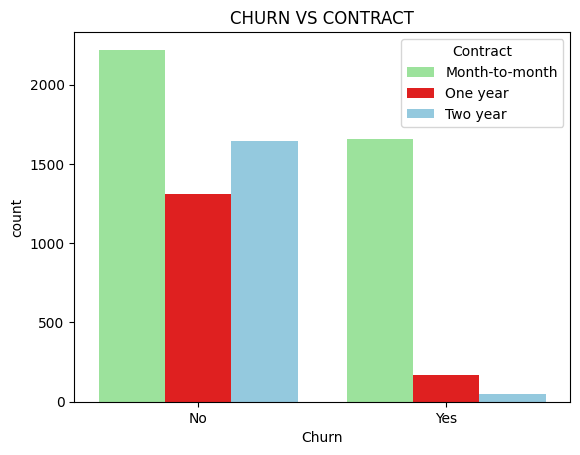

In [49]:
sns.countplot(df,x='Churn',hue='Contract',palette=('lightgreen','red','skyblue'))
plt.title('CHURN VS CONTRACT')

-HERE IT WAS SHOWING CLEARLY THAT TWO-YEAR CONTRACT CUSTOMERS HAVE LESS CHURN

-AND ALSO WITH ONE-YEAR CONTRACT CUSTOMERS THE CHURN IS LESS NOT THAT MUCH HIGH COMPARED TO THE MONTHLY CONTRACT CUSTOMERS

**INSIGHT:**

-CONTRACT IS INFLUENCING THE CUSTOMER CHURN VERY STRONGLY

-CONTRACT IS MORE THAN ONE YAER THE CHURN RATE WILL DECREASE

**PAPERLESS BILLING VS CHURN**

In [50]:
pd.crosstab(df['PaperlessBilling'],df['Churn'],normalize='index')*100

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


-HERE,THE CUSTOMERS RECIEVING THEIR BILLS IN ONLINE ARE CHURNED MORE(34%)

-WHEREAS THE CUSTOMERS WITHOUT PAPERLESSBILLING ARE LESS CHURNED AROUND(16%)

Text(0.5, 1.0, 'CHURN VS PAPERLESSBILLING')

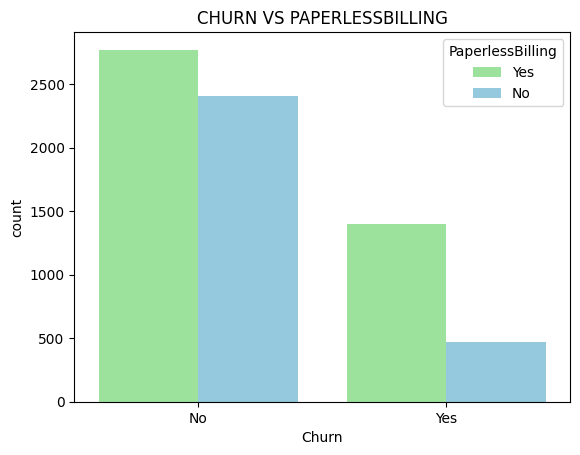

In [51]:
sns.countplot(df,x='Churn',hue='PaperlessBilling',palette=('lightgreen','skyblue'))
plt.title('CHURN VS PAPERLESSBILLING')

-customers with paperlessbilling are having highest churn rate

-customers without paperlessbilling are having less churn

**INSIGHT:**

-PAPERLESSBILLING IS MODERATELY INFLUENCING THE CUSTOMER CHURN

-WITHOUT PAPERLESSBILLING THE CHURN RATE IS LESS

**PAYMENT METHOD VS CHURN**

In [52]:
pd.crosstab(df['PaymentMethod'],df['Churn'],normalize='index')*100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


-CUSTOMERS PAYING BILL USING ELECTRONIC CHECK ARE MORE CHURNED(45%) COMPARED TO OTHER CATEGORIES

-THE REMAINING CATEGORIES ARE VERY SIMILARLY CHURNED AND HAS LESS CHURN RATE AROUND(15-20%)

Text(0.5, 1.0, 'CHURN VS PAYMENTMETHOD')

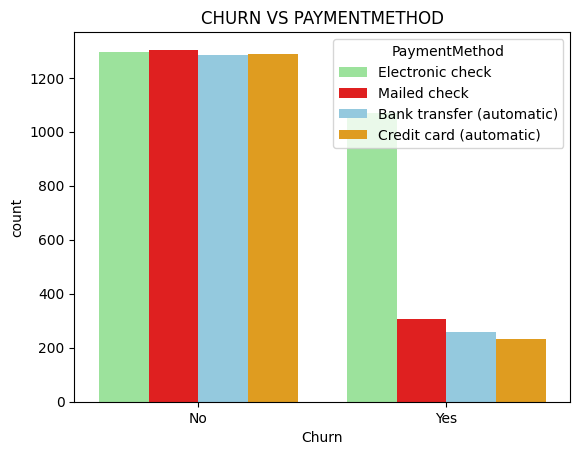

In [53]:
sns.countplot(df,x='Churn',hue='PaymentMethod',palette=('lightgreen','red','skyblue','orange'))
plt.title('CHURN VS PAYMENTMETHOD')

-THE CUSTOMERS ARE EQUALLY RETAINED IN ALL CASES AND ALSO THEY ARE EQUALLY DISTRIBUTED

-THE CHURN IS MORE IN THE ELECTRONIC CHECK PAYMENT METHOD

-AND REMAINING THREE CATEGORIES ARE QUITE SIMILAR IN CHURN RATE

**INSIGHT:**

-PAYMENT METHOD IS MODERATELY INFLUENCING THE CUSTOMER CHURN

-CUSTOMERS USING ELECTRONIC CHECK SHOW HIGHER CHURN RATES. THE COMPANY SHOULD INVESTIGATE THE REASONS AND ENCOURAGE THE ADOPTION OF ALTERNATIVE PAYMENT METHODS

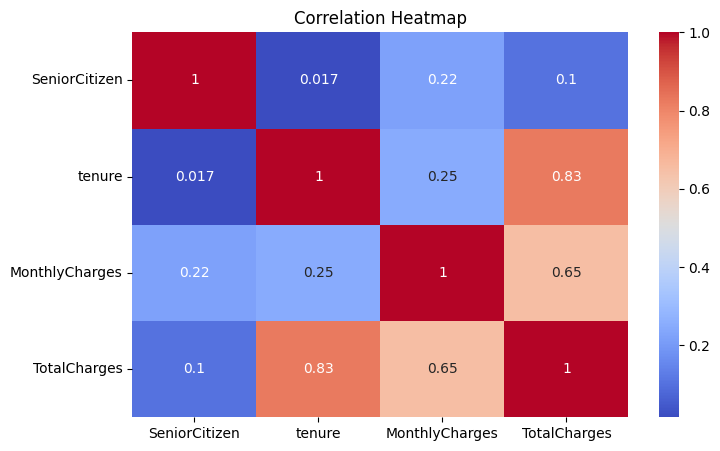

In [54]:
corr_df = df[['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']]
plt.figure(figsize=(8,5))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

-Tenure shows a negative relationship with churn, indicating that customers with longer tenure are less likely to churn. Monthly charges exhibit a positive relationship with churn, while Total Charges are strongly associated with tenure

**KEY INSIGHTS:**

1. CUSTOMERS WITH LOWER TENURE ARE MORE LIKELY TO CHURN, INDICATING THAT CUSTOMER ATTRITION IS HIGHEST DURING THE EARLY STAGES OF THE CUSTOMER LIFECYCLE.

2. CUSTOMERS SUBSCRIBED TO MONTH-TO-MONTH CONTRACTS EXHIBIT SIGNIFICANTLY HIGHER CHURN RATES COMPARED TO CUSTOMERS WITH ONE-YEAR AND TWO-YEAR CONTRACTS.

3. FIBER OPTIC INTERNET USERS SHOW A HIGHER TENDENCY TO CHURN THAN CUSTOMERS USING DSL OR THOSE WITHOUT INTERNET SERVICE.

4. CUSTOMERS WITHOUT ONLINE SECURITY AND TECH SUPPORT SERVICES ARE MORE LIKELY TO CHURN, SUGGESTING THAT VALUE-ADDED SERVICES CONTRIBUTE POSITIVELY TO CUSTOMER RETENTION.

5. CUSTOMERS WITH HIGHER MONTHLY CHARGES EXHIBIT HIGHER CHURN RATES, INDICATING THAT PRICING MAY INFLUENCE CUSTOMER RETENTION DECISIONS.

6. CUSTOMERS USING ELECTRONIC CHECK AS THEIR PAYMENT METHOD EXPERIENCE HIGHER CHURN RATES COMPARED TO CUSTOMERS USING OTHER PAYMENT METHODS.

7. DEMOGRAPHIC FACTORS SUCH AS GENDER HAVE MINIMAL INFLUENCE ON CHURN, WHEREAS SERVICE-RELATED AND CONTRACT-RELATED FACTORS HAVE A MUCH STRONGER IMPACT.

8. LONG-TENURE CUSTOMERS DEMONSTRATE HIGHER RETENTION RATES, INDICATING INCREASED CUSTOMER LOYALTY OVER TIME.

**RECOMMENDATIONS:**

1. IMPLEMENT TARGETED RETENTION PROGRAMS FOR NEW CUSTOMERS DURING THEIR FIRST YEAR OF SERVICE TO REDUCE EARLY-STAGE CHURN.

2. ENCOURAGE CUSTOMERS TO TRANSITION FROM MONTH-TO-MONTH CONTRACTS TO LONG-TERM CONTRACTS THROUGH DISCOUNTS, LOYALTY REWARDS, OR BUNDLED OFFERS.

3. INVESTIGATE THE REASONS BEHIND THE HIGH CHURN RATE AMONG FIBER OPTIC CUSTOMERS AND TAKE CORRECTIVE ACTIONS TO IMPROVE SERVICE QUALITY AND CUSTOMER SATISFACTION.

4. PROMOTE ONLINE SECURITY AND TECH SUPPORT SERVICES THROUGH BUNDLED PACKAGES AND PROMOTIONAL CAMPAIGNS TO INCREASE CUSTOMER ENGAGEMENT AND RETENTION.

5. REVIEW PRICING STRATEGIES FOR CUSTOMERS WITH HIGH MONTHLY CHARGES AND INTRODUCE PERSONALIZED OFFERS WHERE APPROPRIATE.

6. ANALYZE CUSTOMER EXPERIENCES ASSOCIATED WITH ELECTRONIC CHECK PAYMENTS AND ENCOURAGE THE ADOPTION OF ALTERNATIVE PAYMENT METHODS.

7. DEVELOP LOYALTY PROGRAMS FOR LONG-TERM CUSTOMERS TO STRENGTHEN CUSTOMER RELATIONSHIPS AND FURTHER IMPROVE RETENTION.

8. CONTINUOUSLY MONITOR CUSTOMER BEHAVIOR AND PROACTIVELY IDENTIFY HIGH-RISK CUSTOMERS FOR TARGETED RETENTION INITIATIVES.


**CONCLUSION:**

THE ANALYSIS IDENTIFIED TENURE, CONTRACT TYPE, INTERNET SERVICE, VALUE-ADDED SERVICES, MONTHLY CHARGES, AND PAYMENT METHOD AS THE MAJOR FACTORS INFLUENCING CUSTOMER CHURN. BY FOCUSING ON CUSTOMER RETENTION STRATEGIES, SERVICE QUALITY IMPROVEMENTS, AND LONG-TERM CUSTOMER ENGAGEMENT, THE COMPANY CAN REDUCE CHURN AND IMPROVE CUSTOMER LOYALTY.